# HR Employee Attrition Analysis

## Project Objective

Analyze employee characteristics and identify the major factors associated with employee attrition.

### Key Business Question
Which employee segments are more likely to leave, and what factors are associated with higher attrition?

### Tools Used
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- SciPy


In [2]:
import pandas as pd
import numpy as np

## 2. Load Dataset


In [3]:
df = pd.read_csv("../data/raw/WA_Fn-UseC_-HR-Employee-Attrition.csv")

## 3. Data Understanding


In [4]:
df.shape

(1470, 35)

In [5]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [6]:
df.tail()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,4,80,0,17,3,2,9,6,0,8
1469,34,No,Travel_Rarely,628,Research & Development,8,3,Medical,1,2068,...,1,80,0,6,3,4,4,3,1,2


In [7]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

## 4. Data Quality Checks


In [9]:
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [10]:
df.duplicated().sum()

0

In [11]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [12]:
df.select_dtypes(include="object").columns

Index(['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender',
       'JobRole', 'MaritalStatus', 'Over18', 'OverTime'],
      dtype='object')

In [13]:
df["EmployeeNumber"].nunique()

1470

In [14]:
df.select_dtypes(include="object").columns

Index(['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender',
       'JobRole', 'MaritalStatus', 'Over18', 'OverTime'],
      dtype='object')

In [15]:
for col in df.select_dtypes(include="object").columns:
    print(f"\n{col}")
    print(df[col].unique())


Attrition
['Yes' 'No']

BusinessTravel
['Travel_Rarely' 'Travel_Frequently' 'Non-Travel']

Department
['Sales' 'Research & Development' 'Human Resources']

EducationField
['Life Sciences' 'Other' 'Medical' 'Marketing' 'Technical Degree'
 'Human Resources']

Gender
['Female' 'Male']

JobRole
['Sales Executive' 'Research Scientist' 'Laboratory Technician'
 'Manufacturing Director' 'Healthcare Representative' 'Manager'
 'Sales Representative' 'Research Director' 'Human Resources']

MaritalStatus
['Single' 'Married' 'Divorced']

Over18
['Y']

OverTime
['Yes' 'No']


## 5. Feature Engineering


In [16]:
df["TenureGroup"]=pd.cut(df["YearsAtCompany"],bins=[0,2,5,10,np.inf],labels=["0-2 Years","3-5 Years","6-10 Years","11+ Years"],include_lowest=True)

In [17]:
df["TenureGroup"].value_counts()

TenureGroup
6-10 Years    448
3-5 Years     434
0-2 Years     342
11+ Years     246
Name: count, dtype: int64

In [18]:
df[["YearsAtCompany", "TenureGroup"]].head(20)

,YearsAtCompany,TenureGroup
0,6,6-10 Years
1,10,6-10 Years
2,0,0-2 Years
3,8,6-10 Years
4,2,0-2 Years
5,7,6-10 Years
6,1,0-2 Years
7,1,0-2 Years
8,9,6-10 Years
9,7,6-10 Years


In [19]:
df["TenureGroup"].value_counts().sort_index()
df.groupby("TenureGroup", observed=True)["Attrition"].apply(
    lambda x: (x == "Yes").mean()*100
)

TenureGroup
0-2 Years     29.824561
3-5 Years     13.824885
6-10 Years    12.276786
11+ Years      8.130081
Name: Attrition, dtype: float64

In [20]:
df["IncomeBand"] = pd.cut(
    df["MonthlyIncome"],
    bins=[0, 2999, 4999, 7999, 11999, np.inf],
    labels=["<3000", "3000-4999", "5000-7999", "8000-11999", "12000+"],
    include_lowest=True
)

In [21]:
df["IncomeBand"].value_counts().sort_index()

IncomeBand
<3000         395
3000-4999     354
5000-7999     340
8000-11999    186
12000+        195
Name: count, dtype: int64

In [22]:
df.groupby("IncomeBand", observed=True)["Attrition"].apply(
    lambda x: (x == "Yes").mean() * 100
)

IncomeBand
<3000         28.607595
3000-4999     14.124294
5000-7999     10.000000
8000-11999    15.591398
12000+         5.641026
Name: Attrition, dtype: float64

In [23]:
df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[0, 24, 34, 44, np.inf],
    labels=["<25", "25-34", "35-44", "45+"],
    include_lowest=True
)

In [24]:
df["AgeGroup"].value_counts().sort_index()

AgeGroup
<25       97
25-34    554
35-44    505
45+      314
Name: count, dtype: int64

In [25]:
df["DistanceGroup"] = pd.cut(
    df["DistanceFromHome"],
    bins=[0, 5, 10, 20, np.inf],
    labels=["0-5", "6-10", "11-20", "21+"],
    include_lowest=True
)

In [26]:
df["DistanceGroup"].value_counts().sort_index()

DistanceGroup
0-5      632
6-10     394
11-20    240
21+      204
Name: count, dtype: int64

In [27]:
df.shape

(1470, 39)

In [28]:
education_map = {
    1: "Below College",
    2: "College",
    3: "Bachelor",
    4: "Master",
    5: "Doctor"
}

df["EducationLabel"] = df["Education"].map(education_map)

In [29]:
df[["Education", "EducationLabel"]].head(10)

,Education,EducationLabel
0,2,College
1,1,Below College
2,2,College
3,4,Master
4,1,Below College
5,2,College
6,3,Bachelor
7,1,Below College
8,3,Bachelor
9,3,Bachelor


In [30]:
satisfaction_map = {
    1: "Low",
    2: "Medium",
    3: "High",
    4: "Very High"
}

df["JobSatisfactionLabel"] = df["JobSatisfaction"].map(satisfaction_map)

In [31]:
df[["JobSatisfaction", "JobSatisfactionLabel"]].head(10)

,JobSatisfaction,JobSatisfactionLabel
0,4,Very High
1,2,Medium
2,3,High
3,3,High
4,2,Medium
5,4,Very High
6,1,Low
7,3,High
8,3,High
9,3,High


In [32]:
df["EnvironmentSatisfactionLabel"] = (
    df["EnvironmentSatisfaction"].map(satisfaction_map)
)

In [33]:
worklife_map = {
    1: "Bad",
    2: "Good",
    3: "Better",
    4: "Best"
}

df["WorkLifeBalanceLabel"] = df["WorkLifeBalance"].map(worklife_map)

In [34]:
df["JobInvolvementLabel"] = df["JobInvolvement"].map(satisfaction_map)
df["RelationshipSatisfactionLabel"] = (
    df["RelationshipSatisfaction"].map(satisfaction_map)
)

In [35]:
performance_map = {
    1: "Low",
    2: "Good",
    3: "Excellent",
    4: "Outstanding"
}

df["PerformanceRatingLabel"] = (
    df["PerformanceRating"].map(performance_map)
)

In [36]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager', 'TenureGroup', 'IncomeBand', 'AgeGroup',
       'DistanceGroup', 'EducationLabel', 'JobSatisfactionLabel',
       'EnvironmentSatisfactionLabel', 'WorkLifeBalanceLabel',
       'JobInvolvementLabel', 'RelationshipSatisfactionLabel',
       'PerformanceRatingLabel'],
      dtype='object')

In [37]:
df[
    [
        "EducationLabel",
        "JobSatisfactionLabel",
        "EnvironmentSatisfactionLabel",
        "WorkLifeBalanceLabel",
        "JobInvolvementLabel",
        "RelationshipSatisfactionLabel",
        "PerformanceRatingLabel"
    ]
].isnull().sum()

EducationLabel                   0
JobSatisfactionLabel             0
EnvironmentSatisfactionLabel     0
WorkLifeBalanceLabel             0
JobInvolvementLabel              0
RelationshipSatisfactionLabel    0
PerformanceRatingLabel           0
dtype: int64

## 6. Exploratory Data Analysis


In [38]:
df.groupby("Department").size()

Department
Human Resources            63
Research & Development    961
Sales                     446
dtype: int64

In [39]:
df.groupby("JobRole").size()

JobRole
Healthcare Representative    131
Human Resources               52
Laboratory Technician        259
Manager                      102
Manufacturing Director       145
Research Director             80
Research Scientist           292
Sales Executive              326
Sales Representative          83
dtype: int64

In [40]:
df.groupby("Department")["Attrition"].apply(lambda x:(x=='Yes').mean()*100)

Department
Human Resources           19.047619
Research & Development    13.839750
Sales                     20.627803
Name: Attrition, dtype: float64

In [41]:
department_summary = (
    df.groupby("Department")
      .size()
      .reset_index(name="TotalEmployees")
)
print(department_summary)

               Department  TotalEmployees
0         Human Resources              63
1  Research & Development             961
2                   Sales             446


In [42]:
employees_left = (
    df[df["Attrition"] == "Yes"]
    .groupby("Department")
    .size()
    .reset_index(name="EmployeesLeft")
)
print(employees_left)

               Department  EmployeesLeft
0         Human Resources             12
1  Research & Development            133
2                   Sales             92


In [43]:
department_summary = (
    df.groupby("Department")
      .agg(
          TotalEmployees=("EmployeeNumber", "count"),
          EmployeesLeft=("Attrition", lambda x: (x == "Yes").sum())
      )
      .reset_index()
)

In [44]:
print(department_summary)

               Department  TotalEmployees  EmployeesLeft
0         Human Resources              63             12
1  Research & Development             961            133
2                   Sales             446             92


In [45]:
department_summary["AttritionRate"] = (
    department_summary["EmployeesLeft"]
    / department_summary["TotalEmployees"]
    * 100
).round(2)

In [46]:
jobrole_summary = (
    df.groupby("JobRole")
      .agg(
          TotalEmployees=("EmployeeNumber", "count"),
          EmployeesLeft=("Attrition", lambda x: (x == "Yes").sum())
      )
      .reset_index()
)

In [47]:
jobrole_summary["AttritionRate"] = (
    jobrole_summary["EmployeesLeft"]
    / jobrole_summary["TotalEmployees"]
    * 100
).round(2)


In [48]:
jobrole_summary["AttritionRate"]

0     6.87
1    23.08
2    23.94
3     4.90
4     6.90
5     2.50
6    16.10
7    17.48
8    39.76
Name: AttritionRate, dtype: float64

In [49]:
role_overtime_summary = (
    df.groupby(["JobRole", "OverTime"])
      .agg(
          TotalEmployees=("EmployeeNumber", "count"),
          EmployeesLeft=("Attrition", lambda x: (x == "Yes").sum())
      )
      .reset_index()
)

In [50]:
role_overtime_summary["AttritionRate"] = (
    role_overtime_summary["EmployeesLeft"]
    / role_overtime_summary["TotalEmployees"]
    * 100
).round(2)

In [51]:
role_overtime_summary = role_overtime_summary.sort_values(
    "AttritionRate",
    ascending=False
)

In [52]:
role_overtime_summary

,JobRole,OverTime,TotalEmployees,EmployeesLeft,AttritionRate
17,Sales Representative,Yes,24,16,66.67
5,Laboratory Technician,Yes,62,31,50.00
3,Human Resources,Yes,13,5,38.46
13,Research Scientist,Yes,97,33,34.02
15,Sales Executive,Yes,94,31,32.98
16,Sales Representative,No,59,17,28.81
2,Human Resources,No,39,7,17.95
4,Laboratory Technician,No,197,31,15.74
7,Manager,Yes,27,4,14.81
14,Sales Executive,No,232,26,11.21


In [53]:
role_overtime_tenure = (
    df.groupby(["JobRole", "OverTime", "TenureGroup"], observed=True)
      .agg(
          TotalEmployees=("EmployeeNumber", "count"),
          EmployeesLeft=("Attrition", lambda x: (x == "Yes").sum())
      )
      .reset_index()
)

In [54]:
role_overtime_tenure["AttritionRate"] = (
    role_overtime_tenure["EmployeesLeft"]
    / role_overtime_tenure["TotalEmployees"]
    * 100
).round(2)

In [55]:
role_overtime_tenure = role_overtime_tenure.sort_values(
    "AttritionRate",
    ascending=False
)

In [56]:
role_overtime_tenure.head(15)

,JobRole,OverTime,TenureGroup,TotalEmployees,EmployeesLeft,AttritionRate
68,Sales Representative,Yes,0-2 Years,10,8,80.00
69,Sales Representative,Yes,3-5 Years,10,7,70.00
20,Laboratory Technician,Yes,0-2 Years,28,18,64.29
60,Sales Executive,Yes,0-2 Years,16,10,62.50
13,Human Resources,Yes,3-5 Years,6,3,50.00
21,Laboratory Technician,Yes,3-5 Years,14,7,50.00
11,Human Resources,No,11+ Years,2,1,50.00
12,Human Resources,Yes,0-2 Years,2,1,50.00
52,Research Scientist,Yes,0-2 Years,29,14,48.28
8,Human Resources,No,0-2 Years,11,5,45.45


In [57]:
reliable_segments = role_overtime_tenure[
    role_overtime_tenure["TotalEmployees"] >= 10
]

In [58]:
reliable_segments.sort_values(
    "AttritionRate",
    ascending=False
).head(10)

,JobRole,OverTime,TenureGroup,TotalEmployees,EmployeesLeft,AttritionRate
68,Sales Representative,Yes,0-2 Years,10,8,80.00
69,Sales Representative,Yes,3-5 Years,10,7,70.00
20,Laboratory Technician,Yes,0-2 Years,28,18,64.29
60,Sales Executive,Yes,0-2 Years,16,10,62.50
21,Laboratory Technician,Yes,3-5 Years,14,7,50.00
52,Research Scientist,Yes,0-2 Years,29,14,48.28
8,Human Resources,No,0-2 Years,11,5,45.45
22,Laboratory Technician,Yes,6-10 Years,17,6,35.29
54,Research Scientist,Yes,6-10 Years,26,9,34.62
64,Sales Representative,No,0-2 Years,38,13,34.21


In [59]:
pivot=pd.pivot_table(df,index="JobRole",columns="OverTime",values="Attrition",aggfunc=lambda x:(x=="Yes").mean()*100)
pivot.round(2)

OverTime,No,Yes
JobRole,,
Healthcare Representative,7.45,5.41
Human Resources,17.95,38.46
Laboratory Technician,15.74,50.00
Manager,1.33,14.81
Manufacturing Director,5.66,10.26
Research Director,1.75,4.35
Research Scientist,7.18,34.02
Sales Executive,11.21,32.98
Sales Representative,28.81,66.67


In [60]:
count_pivot=pd.pivot_table(df,index="JobRole",columns="OverTime",values="EmployeeNumber",aggfunc="count")
count_pivot

OverTime,No,Yes
JobRole,,
Healthcare Representative,94,37
Human Resources,39,13
Laboratory Technician,197,62
Manager,75,27
Manufacturing Director,106,39
Research Director,57,23
Research Scientist,195,97
Sales Executive,232,94
Sales Representative,59,24


In [61]:
tenure_overtime_pivot = pd.pivot_table(
    df,
    index="TenureGroup",
    columns="OverTime",
    values="Attrition",
    aggfunc=lambda x: (x == "Yes").mean() * 100
)

tenure_overtime_pivot.round(2)


OverTime,No,Yes
TenureGroup,,
0-2 Years,20.59,50.96
3-5 Years,7.82,28.35
6-10 Years,7.32,25.83
11+ Years,7.18,10.77


## 8. Statistical Analysis — Chi-Square Test


In [62]:
from scipy.stats import chi2_contingency

In [63]:
contingency = pd.crosstab(
    df["OverTime"],
    df["Attrition"]
)

contingency

Attrition,No,Yes
OverTime,,
No,944,110
Yes,289,127


## 7. Statistical Analysis — Welch's T-Test


In [64]:
chi2, p_value, dof, expected = chi2_contingency(contingency)

print("Chi-square statistic:", chi2)
print("p-value:", p_value)

if p_value < 0.05:
    print("Statistically significant association")
else:
    print("No statistically significant association")

Chi-square statistic: 87.56429365828768
p-value: 8.158423721538322e-21
Statistically significant association


In [65]:

def chi_square_test(df, column, target="Attrition"):
    contingency = pd.crosstab(df[column], df[target])
    chi2, p_value, dof, expected = chi2_contingency(contingency)

    return chi2, p_value

In [66]:
categorical_features = [
    "OverTime",
    "BusinessTravel",
    "Department",
    "JobRole",
    "MaritalStatus",
    "Gender",
    "EducationField"
]

In [67]:
results = []

for feature in categorical_features:
    chi2, p_value = chi_square_test(df, feature)

    results.append({
        "Feature": feature,
        "ChiSquare": chi2,
        "PValue": p_value
    })

chi_square_results = pd.DataFrame(results)
chi_square_results

,Feature,ChiSquare,PValue
0,OverTime,87.564294,8.158424e-21
1,BusinessTravel,24.182414,5.608614e-06
2,Department,10.796007,4.525607e-03
3,JobRole,86.190254,2.752482e-15
4,MaritalStatus,46.163677,9.455511e-11
5,Gender,1.116967,2.905724e-01
6,EducationField,16.024674,6.773980e-03


In [68]:
chi_square_results["Significant"] = (
    chi_square_results["PValue"] < 0.05
)
chi_square_results.sort_values("PValue")

,Feature,ChiSquare,PValue,Significant
0,OverTime,87.564294,8.158424e-21,True
3,JobRole,86.190254,2.752482e-15,True
4,MaritalStatus,46.163677,9.455511e-11,True
1,BusinessTravel,24.182414,5.608614e-06,True
2,Department,10.796007,4.525607e-03,True
6,EducationField,16.024674,6.773980e-03,True
5,Gender,1.116967,2.905724e-01,False


In [69]:
from scipy.stats import ttest_ind

In [70]:
stayed = df[df["Attrition"] == "No"]
left = df[df["Attrition"] == "Yes"]

In [71]:
t_stat, p_value = ttest_ind(
    stayed["Age"],
    left["Age"],
    equal_var=False
)

print("t-statistic:", t_stat)
print("p-value:", p_value)

t-statistic: 5.82801185398895
p-value: 1.3797600649439775e-08


In [72]:
numeric_features = [
    "Age",
    "MonthlyIncome",
    "YearsAtCompany",
    "YearsInCurrentRole",
    "YearsSinceLastPromotion",
    "DistanceFromHome"
]

In [73]:
results = []

for feature in numeric_features:

    t_stat, p_value = ttest_ind(
        stayed[feature],
        left[feature],
        equal_var=False
    )

    results.append({
        "Feature": feature,
        "T_Statistic": t_stat,
        "PValue": p_value
    })

ttest_results = pd.DataFrame(results)
ttest_results.sort_values("PValue")


,Feature,T_Statistic,PValue
1,MonthlyIncome,7.482622,4.433589e-13
3,YearsInCurrentRole,6.847079,3.187390e-11
0,Age,5.828012,1.379760e-08
2,YearsAtCompany,5.282596,2.285905e-07
5,DistanceFromHome,-2.888183,4.136512e-03
4,YearsSinceLastPromotion,1.287927,1.986513e-01


In [74]:
results = []

for feature in numeric_features:

    t_stat, p_value = ttest_ind(
        stayed[feature],
        left[feature],
        equal_var=False
    )

    results.append({
        "Feature": feature,
        "StayedMean": stayed[feature].mean(),
        "LeftMean": left[feature].mean(),
        "MeanDifference": left[feature].mean() - stayed[feature].mean(),
        "T_Statistic": t_stat,
        "PValue": p_value
    })

ttest_results = pd.DataFrame(results)

ttest_results.sort_values("PValue")

,Feature,StayedMean,LeftMean,MeanDifference,T_Statistic,PValue
1,MonthlyIncome,6832.739659,4787.092827,-2045.646832,7.482622,4.433589e-13
3,YearsInCurrentRole,4.484185,2.902954,-1.581231,6.847079,3.187390e-11
0,Age,37.561233,33.607595,-3.953638,5.828012,1.379760e-08
2,YearsAtCompany,7.369019,5.130802,-2.238217,5.282596,2.285905e-07
5,DistanceFromHome,8.915653,10.632911,1.717259,-2.888183,4.136512e-03
4,YearsSinceLastPromotion,2.234388,1.945148,-0.289240,1.287927,1.986513e-01


In [75]:

def cohens_d(group1, group2):
    n1 = len(group1)
    n2 = len(group2)

    s1 = group1.std()
    s2 = group2.std()

    pooled_std = np.sqrt(
        ((n1 - 1) * s1**2 + (n2 - 1) * s2**2)
        / (n1 + n2 - 2)
    )

    d = (group1.mean() - group2.mean()) / pooled_std

    return d

## 9. Practical Effect Size — Cohen's d


In [76]:
d = cohens_d(
    stayed["MonthlyIncome"],
    left["MonthlyIncome"]
)

print("Cohen's d:", d)
print("Absolute effect size:", abs(d))

Cohen's d: 0.44001780335915724
Absolute effect size: 0.44001780335915724


In [77]:
effect_results = []

for feature in numeric_features:

    d = cohens_d(
        stayed[feature],
        left[feature]
    )

    effect_results.append({
        "Feature": feature,
        "CohensD": d,
        "AbsoluteEffectSize": abs(d)
    })

effect_results = pd.DataFrame(effect_results)

In [78]:
effect_results.sort_values(
    "AbsoluteEffectSize",
    ascending=False
)

,Feature,CohensD,AbsoluteEffectSize
3,YearsInCurrentRole,0.442011,0.442011
1,MonthlyIncome,0.440018,0.440018
0,Age,0.438225,0.438225
2,YearsAtCompany,0.368551,0.368551
5,DistanceFromHome,-0.212401,0.212401
4,YearsSinceLastPromotion,0.089777,0.089777


In [79]:
numeric_statistics = ttest_results.merge(
    effect_results,
    on="Feature"
)

In [80]:
numeric_statistics.sort_values(
    "PValue"
)

,Feature,StayedMean,LeftMean,MeanDifference,T_Statistic,PValue,CohensD,AbsoluteEffectSize
1,MonthlyIncome,6832.739659,4787.092827,-2045.646832,7.482622,4.433589e-13,0.440018,0.440018
3,YearsInCurrentRole,4.484185,2.902954,-1.581231,6.847079,3.187390e-11,0.442011,0.442011
0,Age,37.561233,33.607595,-3.953638,5.828012,1.379760e-08,0.438225,0.438225
2,YearsAtCompany,7.369019,5.130802,-2.238217,5.282596,2.285905e-07,0.368551,0.368551
5,DistanceFromHome,8.915653,10.632911,1.717259,-2.888183,4.136512e-03,-0.212401,0.212401
4,YearsSinceLastPromotion,2.234388,1.945148,-0.289240,1.287927,1.986513e-01,0.089777,0.089777


In [81]:
numeric_cols = [
    "Age",
    "DistanceFromHome",
    "MonthlyIncome",
    "YearsAtCompany",
    "YearsInCurrentRole",
    "YearsSinceLastPromotion",
    "YearsWithCurrManager"
]

## 10. Correlation Analysis


In [82]:
corr_matrix = df[numeric_cols].corr()

corr_matrix.round(2)

,Age,DistanceFromHome,MonthlyIncome,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
Age,1.00,-0.00,0.50,0.31,0.21,0.22,0.20
DistanceFromHome,-0.00,1.00,-0.02,0.01,0.02,0.01,0.01
MonthlyIncome,0.50,-0.02,1.00,0.51,0.36,0.34,0.34
YearsAtCompany,0.31,0.01,0.51,1.00,0.76,0.62,0.77
YearsInCurrentRole,0.21,0.02,0.36,0.76,1.00,0.55,0.71
YearsSinceLastPromotion,0.22,0.01,0.34,0.62,0.55,1.00,0.51
YearsWithCurrManager,0.20,0.01,0.34,0.77,0.71,0.51,1.00


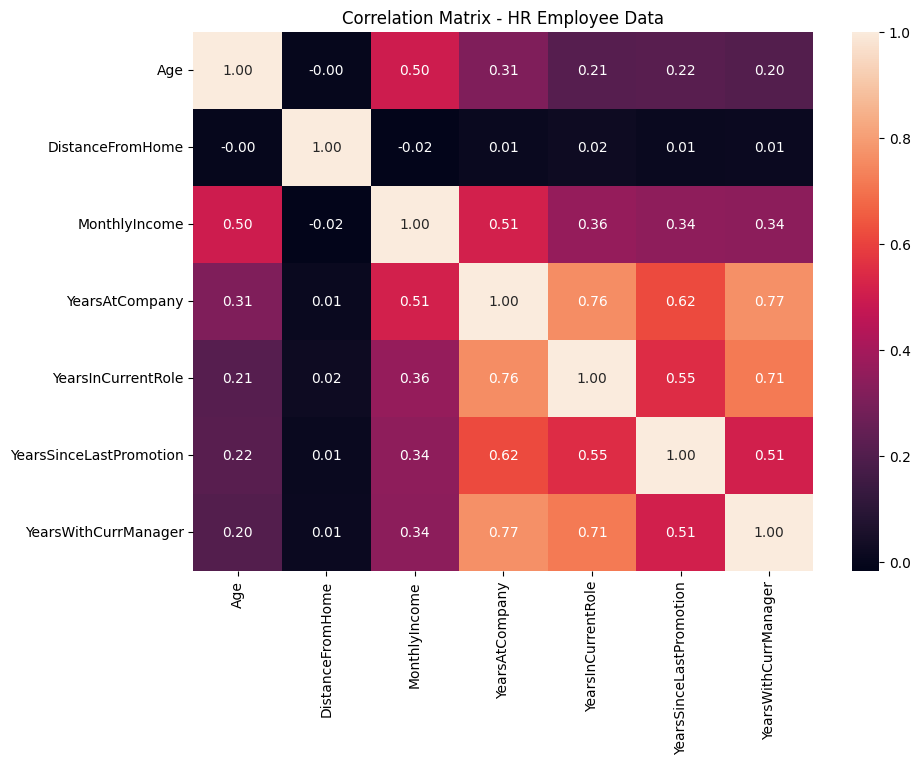

In [83]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Matrix - HR Employee Data")
plt.show()

In [84]:
corr_pairs = (
    corr_matrix
    .unstack()
    .sort_values(ascending=False)
)

In [85]:
corr_pairs = corr_pairs[corr_pairs.abs() < 1]

In [86]:
corr_pairs.head(10)

YearsWithCurrManager     YearsAtCompany             0.769212
YearsAtCompany           YearsWithCurrManager       0.769212
                         YearsInCurrentRole         0.758754
YearsInCurrentRole       YearsAtCompany             0.758754
                         YearsWithCurrManager       0.714365
YearsWithCurrManager     YearsInCurrentRole         0.714365
YearsSinceLastPromotion  YearsAtCompany             0.618409
YearsAtCompany           YearsSinceLastPromotion    0.618409
YearsInCurrentRole       YearsSinceLastPromotion    0.548056
YearsSinceLastPromotion  YearsInCurrentRole         0.548056
dtype: float64

In [87]:
corr_pairs.sort_values().head(10)

DistanceFromHome         MonthlyIncome             -0.017014
MonthlyIncome            DistanceFromHome          -0.017014
DistanceFromHome         Age                       -0.001686
Age                      DistanceFromHome          -0.001686
YearsAtCompany           DistanceFromHome           0.009508
DistanceFromHome         YearsAtCompany             0.009508
                         YearsSinceLastPromotion    0.010029
YearsSinceLastPromotion  DistanceFromHome           0.010029
DistanceFromHome         YearsWithCurrManager       0.014406
YearsWithCurrManager     DistanceFromHome           0.014406
dtype: float64

In [88]:
corr_matrix = df[numeric_cols].corr()
corr_matrix.round(2)

,Age,DistanceFromHome,MonthlyIncome,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
Age,1.00,-0.00,0.50,0.31,0.21,0.22,0.20
DistanceFromHome,-0.00,1.00,-0.02,0.01,0.02,0.01,0.01
MonthlyIncome,0.50,-0.02,1.00,0.51,0.36,0.34,0.34
YearsAtCompany,0.31,0.01,0.51,1.00,0.76,0.62,0.77
YearsInCurrentRole,0.21,0.02,0.36,0.76,1.00,0.55,0.71
YearsSinceLastPromotion,0.22,0.01,0.34,0.62,0.55,1.00,0.51
YearsWithCurrManager,0.20,0.01,0.34,0.77,0.71,0.51,1.00


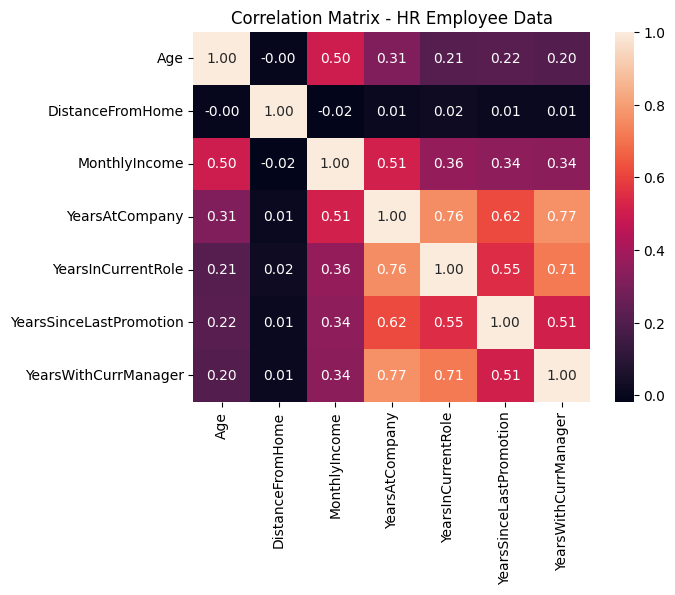

In [89]:
sns.heatmap(corr_matrix, annot=True, fmt=".2f")
plt.title("Correlation Matrix - HR Employee Data")
plt.show()

In [90]:
corr_pairs = corr_matrix.unstack().sort_values(ascending=False)
corr_pairs = corr_pairs[corr_pairs.abs() < 1]

corr_pairs.head(10)

YearsWithCurrManager     YearsAtCompany             0.769212
YearsAtCompany           YearsWithCurrManager       0.769212
                         YearsInCurrentRole         0.758754
YearsInCurrentRole       YearsAtCompany             0.758754
                         YearsWithCurrManager       0.714365
YearsWithCurrManager     YearsInCurrentRole         0.714365
YearsSinceLastPromotion  YearsAtCompany             0.618409
YearsAtCompany           YearsSinceLastPromotion    0.618409
YearsInCurrentRole       YearsSinceLastPromotion    0.548056
YearsSinceLastPromotion  YearsInCurrentRole         0.548056
dtype: float64

c:\Users\nandi\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\nandi\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\nandi\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


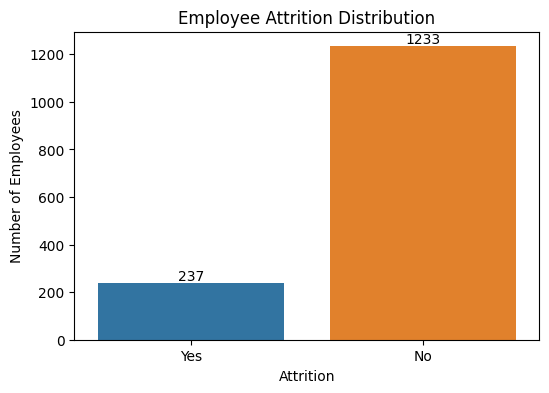

In [92]:

plt.figure(figsize=(6, 4))

ax = sns.countplot(data=df, x="Attrition")

# Add count labels
ax.bar_label(ax.containers[0])

plt.title("Employee Attrition Distribution")
plt.xlabel("Attrition")
plt.ylabel("Number of Employees")

plt.show()

c:\Users\nandi\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\nandi\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\nandi\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


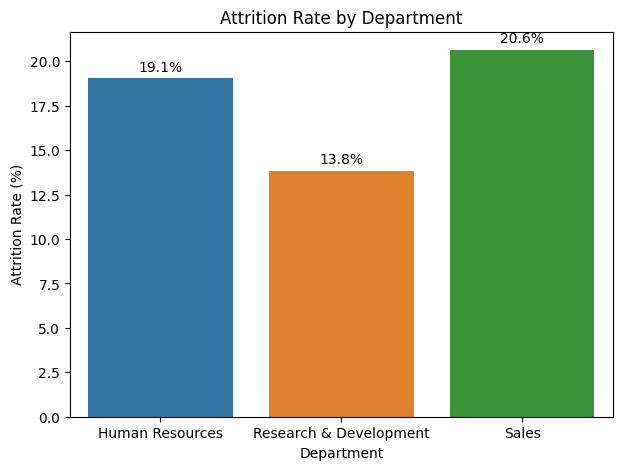

In [93]:

department_summary = (
    df.groupby("Department")
      .agg(
          TotalEmployees=("EmployeeNumber", "count"),
          EmployeesLeft=("Attrition", lambda x: (x == "Yes").sum())
      )
      .reset_index()
)

department_summary["AttritionRate"] = (
    department_summary["EmployeesLeft"] /
    department_summary["TotalEmployees"] * 100
).round(2)

plt.figure(figsize=(7, 5))

ax = sns.barplot(
    data=department_summary,
    x="Department",
    y="AttritionRate"
)

labels = [
    f"{bar.get_height():.1f}%"
    for bar in ax.containers[0]
]

ax.bar_label(ax.containers[0], labels=labels, padding=3)

plt.title("Attrition Rate by Department")
plt.xlabel("Department")
plt.ylabel("Attrition Rate (%)")

plt.show()

c:\Users\nandi\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\nandi\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\nandi\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


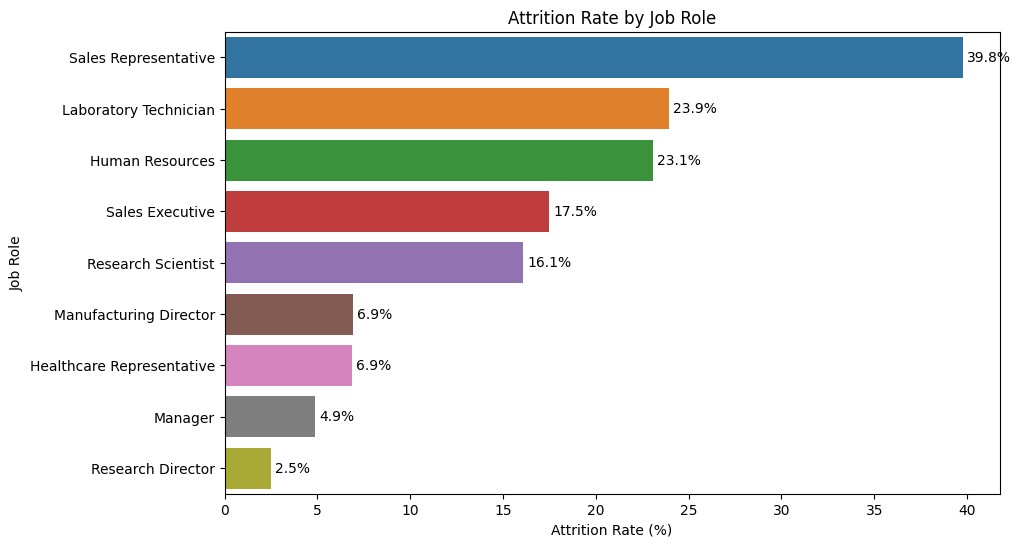

In [94]:

jobrole_summary = (
    df.groupby("JobRole")
      .agg(
          TotalEmployees=("EmployeeNumber", "count"),
          EmployeesLeft=("Attrition", lambda x: (x == "Yes").sum())
      )
      .reset_index()
)

jobrole_summary["AttritionRate"] = (
    jobrole_summary["EmployeesLeft"] /
    jobrole_summary["TotalEmployees"] * 100
).round(2)

# Sort from highest to lowest
jobrole_summary = jobrole_summary.sort_values(
    "AttritionRate",
    ascending=False
)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=jobrole_summary,
    x="AttritionRate",
    y="JobRole"
)

labels = [
    f"{bar.get_width():.1f}%"
    for bar in ax.containers[0]
]

ax.bar_label(
    ax.containers[0],
    labels=labels,
    padding=3
)

plt.title("Attrition Rate by Job Role")
plt.xlabel("Attrition Rate (%)")
plt.ylabel("Job Role")

plt.show()

c:\Users\nandi\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\nandi\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\nandi\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


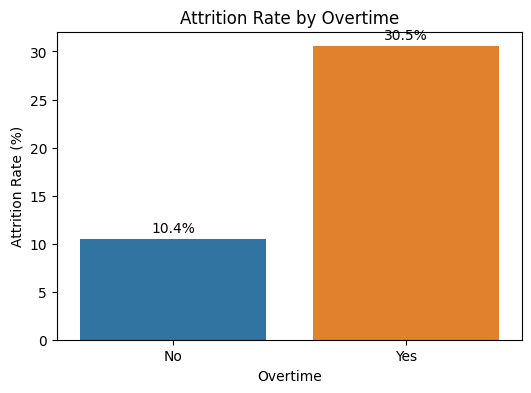

In [95]:

overtime_summary = (
    df.groupby("OverTime")
      .agg(
          TotalEmployees=("EmployeeNumber", "count"),
          EmployeesLeft=("Attrition", lambda x: (x == "Yes").sum())
      )
      .reset_index()
)

overtime_summary["AttritionRate"] = (
    overtime_summary["EmployeesLeft"] /
    overtime_summary["TotalEmployees"] * 100
).round(2)

plt.figure(figsize=(6, 4))

ax = sns.barplot(
    data=overtime_summary,
    x="OverTime",
    y="AttritionRate"
)

labels = [
    f"{bar.get_height():.1f}%"
    for bar in ax.containers[0]
]

ax.bar_label(
    ax.containers[0],
    labels=labels,
    padding=3
)

plt.title("Attrition Rate by Overtime")
plt.xlabel("Overtime")
plt.ylabel("Attrition Rate (%)")

plt.show()

c:\Users\nandi\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\nandi\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


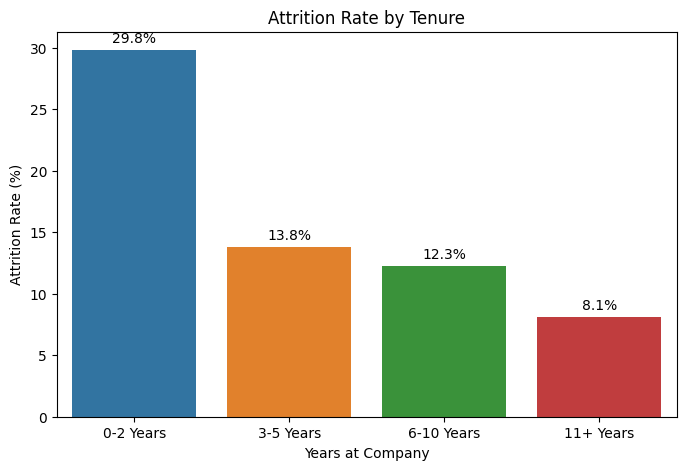

In [96]:

tenure_summary = (
    df.groupby("TenureGroup", observed=True)
      .agg(
          TotalEmployees=("EmployeeNumber", "count"),
          EmployeesLeft=("Attrition", lambda x: (x == "Yes").sum())
      )
      .reset_index()
)

tenure_summary["AttritionRate"] = (
    tenure_summary["EmployeesLeft"] /
    tenure_summary["TotalEmployees"] * 100
).round(2)

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=tenure_summary,
    x="TenureGroup",
    y="AttritionRate"
)

labels = [
    f"{bar.get_height():.1f}%"
    for bar in ax.containers[0]
]

ax.bar_label(
    ax.containers[0],
    labels=labels,
    padding=3
)

plt.title("Attrition Rate by Tenure")
plt.xlabel("Years at Company")
plt.ylabel("Attrition Rate (%)")

plt.show()

c:\Users\nandi\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\nandi\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\nandi\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


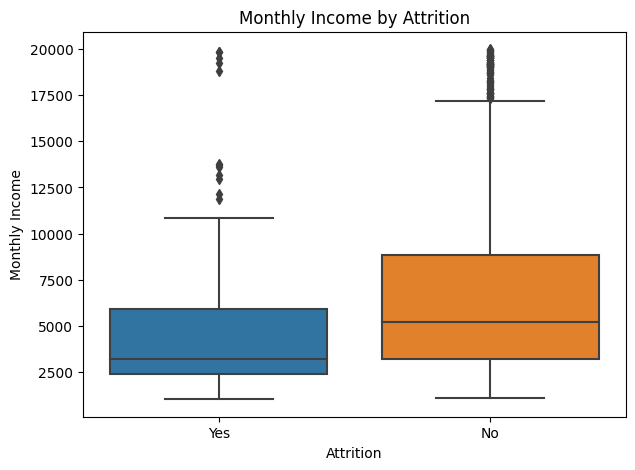

In [97]:

plt.figure(figsize=(7, 5))

ax = sns.boxplot(
    data=df,
    x="Attrition",
    y="MonthlyIncome"
)

plt.title("Monthly Income by Attrition")
plt.xlabel("Attrition")
plt.ylabel("Monthly Income")

plt.show()

c:\Users\nandi\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\nandi\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\nandi\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


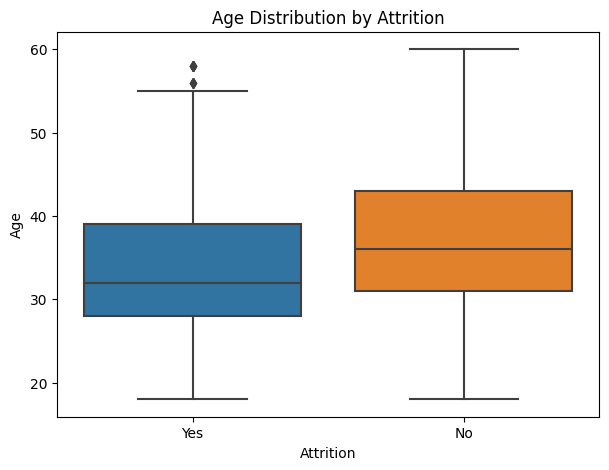

In [98]:

plt.figure(figsize=(7, 5))

ax = sns.boxplot(
    data=df,
    x="Attrition",
    y="Age"
)

plt.title("Age Distribution by Attrition")
plt.xlabel("Attrition")
plt.ylabel("Age")

plt.show()

In [99]:
numeric_cols = [
    "Age",
    "DistanceFromHome",
    "MonthlyIncome",
    "YearsAtCompany",
    "YearsInCurrentRole",
    "YearsSinceLastPromotion",
    "YearsWithCurrManager"
]

corr_matrix = df[numeric_cols].corr()

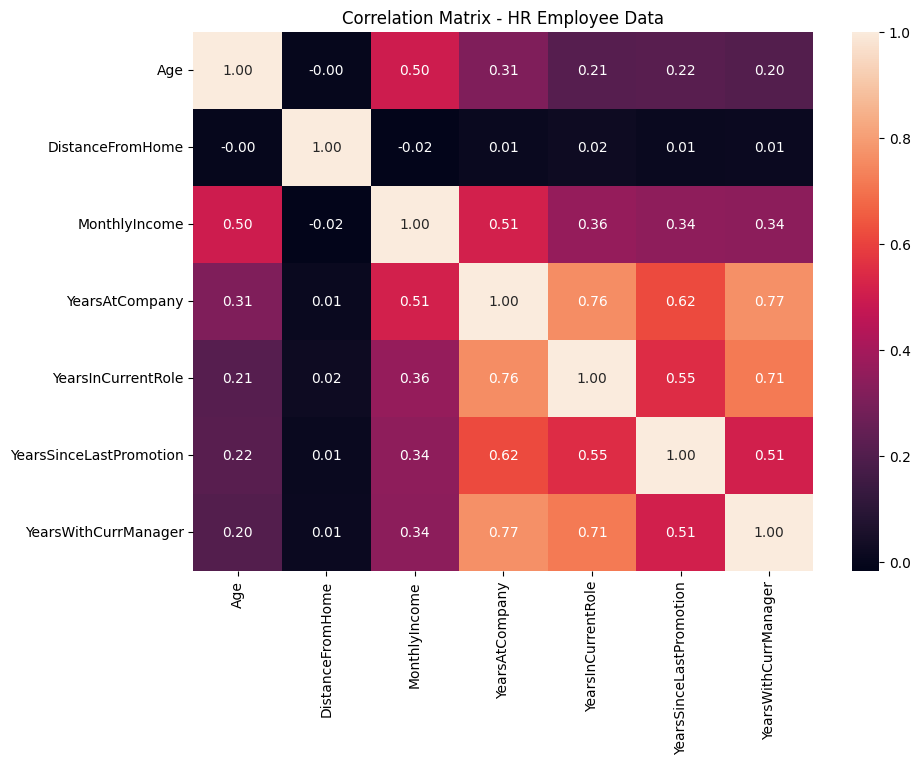

In [100]:

plt.figure(figsize=(10, 7))

ax = sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Matrix - HR Employee Data")

plt.show()

## 11. Export Analysis Results


In [102]:

with pd.ExcelWriter(
    "HR_Attrition_Summary.xlsx",
    engine="openpyxl"
) as writer:

    department_summary.to_excel(
        writer,
        sheet_name="Department Summary",
        index=False
    )

    jobrole_summary.to_excel(
        writer,
        sheet_name="Job Role Summary",
        index=False
    )

    overtime_summary.to_excel(
        writer,
        sheet_name="Overtime Summary",
        index=False
    )

    tenure_summary.to_excel(
        writer,
        sheet_name="Tenure Summary",
        index=False
    )

In [103]:
df.to_excel(
    "HR_Attrition_Full_Data.xlsx",
    sheet_name="Employee Data",
    index=False
)

In [105]:
with pd.ExcelWriter(
    "HR_Attrition_Analysis.xlsx",
    engine="openpyxl"
) as writer:

    # Full dataset
    df.to_excel(
        writer,
        sheet_name="Employee Data",
        index=False
    )

    # Summary tables
    department_summary.to_excel(
        writer,
        sheet_name="Department Summary",
        index=False
    )

    jobrole_summary.to_excel(
        writer,
        sheet_name="Job Role Summary",
        index=False
    )

    overtime_summary.to_excel(
        writer,
        sheet_name="Overtime Summary",
        index=False
    )

    tenure_summary.to_excel(
        writer,
        sheet_name="Tenure Summary",
        index=False
    )

In [106]:

stayed = df[df["Attrition"] == "No"]
left = df[df["Attrition"] == "Yes"]

numeric_features = [
    "MonthlyIncome",
    "YearsInCurrentRole",
    "Age",
    "YearsAtCompany",
    "DistanceFromHome",
    "YearsSinceLastPromotion"
]

results = []

for feature in numeric_features:

    stayed_values = stayed[feature]
    left_values = left[feature]

    t_stat, p_value = ttest_ind(
        stayed_values,
        left_values,
        equal_var=False
    )

    results.append({
        "Feature": feature,
        "Stayed Mean": stayed_values.mean(),
        "Left Mean": left_values.mean(),
        "Difference": left_values.mean() - stayed_values.mean(),
        "P-Value": p_value,
        "Significant": "Yes" if p_value < 0.05 else "No"
    })

ttest_results = pd.DataFrame(results)

ttest_results

,Feature,Stayed Mean,Left Mean,Difference,P-Value,Significant
0,MonthlyIncome,6832.739659,4787.092827,-2045.646832,4.433589e-13,Yes
1,YearsInCurrentRole,4.484185,2.902954,-1.581231,3.187390e-11,Yes
2,Age,37.561233,33.607595,-3.953638,1.379760e-08,Yes
3,YearsAtCompany,7.369019,5.130802,-2.238217,2.285905e-07,Yes
4,DistanceFromHome,8.915653,10.632911,1.717259,4.136512e-03,Yes
5,YearsSinceLastPromotion,2.234388,1.945148,-0.289240,1.986513e-01,No


In [107]:

categorical_features = [
    "OverTime",
    "BusinessTravel",
    "Department",
    "JobRole",
    "MaritalStatus",
    "Gender",
    "EducationField"
]

results = []

for feature in categorical_features:

    contingency = pd.crosstab(
        df[feature],
        df["Attrition"]
    )

    chi2, p_value, dof, expected = chi2_contingency(
        contingency
    )

    results.append({
        "Feature": feature,
        "Chi-Square": chi2,
        "P-Value": p_value,
        "Significant": "Yes" if p_value < 0.05 else "No"
    })

chi_square_results = pd.DataFrame(results)

chi_square_results

,Feature,Chi-Square,P-Value,Significant
0,OverTime,87.564294,8.158424e-21,Yes
1,BusinessTravel,24.182414,5.608614e-06,Yes
2,Department,10.796007,4.525607e-03,Yes
3,JobRole,86.190254,2.752482e-15,Yes
4,MaritalStatus,46.163677,9.455511e-11,Yes
5,Gender,1.116967,2.905724e-01,No
6,EducationField,16.024674,6.773980e-03,Yes


In [108]:
def cohens_d(group1, group2):
    n1 = len(group1)
    n2 = len(group2)

    s1 = group1.std()
    s2 = group2.std()

    pooled_std = np.sqrt(
        ((n1 - 1) * s1**2 + (n2 - 1) * s2**2)
        / (n1 + n2 - 2)
    )

    return (group1.mean() - group2.mean()) / pooled_std


effect_results = []

for feature in numeric_features:

    d = cohens_d(
        stayed[feature],
        left[feature]
    )

    effect_results.append({
        "Feature": feature,
        "Cohens_d": round(d, 2)
    })

effect_size_results = pd.DataFrame(effect_results)

effect_size_results

,Feature,Cohens_d
0,MonthlyIncome,0.44
1,YearsInCurrentRole,0.44
2,Age,0.44
3,YearsAtCompany,0.37
4,DistanceFromHome,-0.21
5,YearsSinceLastPromotion,0.09


In [109]:
with pd.ExcelWriter(
    "HR_Attrition_Statistics.xlsx",
    engine="openpyxl"
) as writer:

    ttest_results.to_excel(
        writer,
        sheet_name="T-Test Results",
        index=False
    )

    chi_square_results.to_excel(
        writer,
        sheet_name="Chi-Square Results",
        index=False
    )

    effect_size_results.to_excel(
        writer,
        sheet_name="Effect Sizes",
        index=False
    )

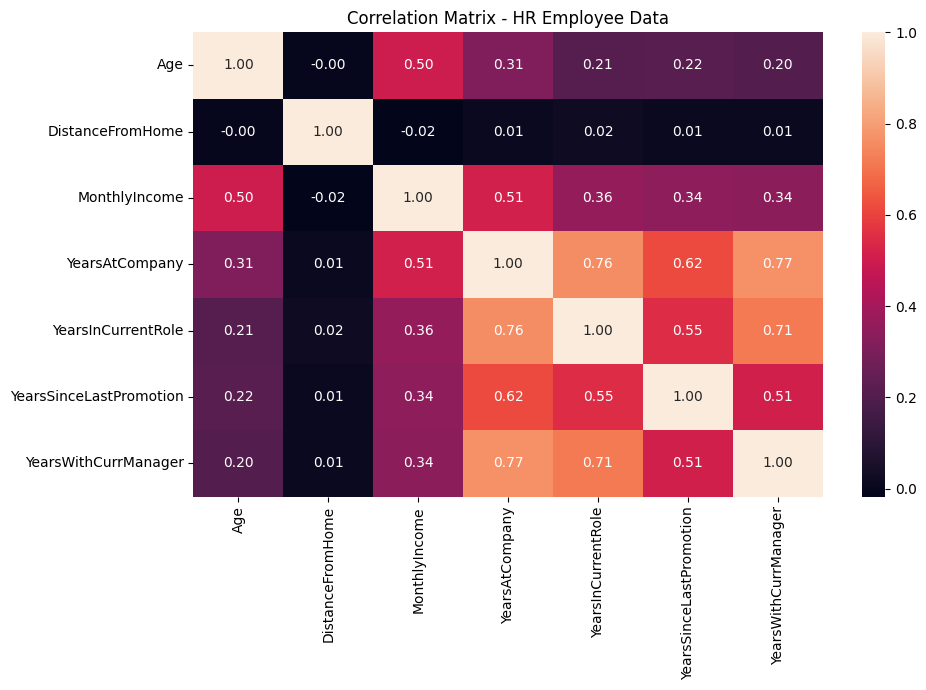

In [110]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Matrix - HR Employee Data")

plt.tight_layout()

plt.savefig("correlation_heatmap.png", dpi=200)

plt.show()

## 12. Business Insights

The analysis highlights employee segments and workplace factors associated with higher observed attrition. These findings should be interpreted as associations in the dataset, not proof that any individual factor directly causes employees to leave.

### Key Areas for HR Attention
- Overtime and workload exposure
- Early-tenure employees
- Lower-income employee segments
- Selected high-risk job roles
- Employee age, tenure, and distance from home
- Job satisfaction and work-life balance
